<a href="https://colab.research.google.com/github/Isai-csbs/isaipriya/blob/main/Copy_of_dma_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages(c("tidyverse", "lubridate", "forecast"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in install.packages(c("tidyverse", "lubridate", "forecast")):
“installation of package ‘lubridate’ had non-zero exit status”
Warning message in install.packages(c("tidyverse", "lubridate", "forecast")):
“installation of package ‘forecast’ had non-zero exit status”


In [ ]:
# ----------------------------------------------------
# STEP 1 & 2: Define Problem & Acquire Data
# ----------------------------------------------------

# Install and load necessary R packages if you haven't already
# install.packages(c("tidyverse", "lubridate", "forecast"))
library(tidyverse)
library(lubridate)
library(forecast)

# Define the Objective (Step 1)
print("Objective: Forecast the total monthly expenses for the next 3 months.")

# Create a MOCK Transaction Dataset (Step 2 - Replace with your actual CSV loading)
set.seed(42)
num_months <- 24
start_date <- ymd("2023-01-01")

# Create a data frame spanning 24 months
mock_data <- tibble(
  Date = seq(start_date, by = "month", length.out = num_months)
) %>%
  # Simulate monthly total spending with a slight upward trend and some noise
  mutate(
    Month = floor_date(Date, "month"),
    BaseExpense = 1500 + (row_number() * 10),
    Noise = rnorm(num_months, mean = 0, sd = 100),
    Total_Expense = round(BaseExpense + Noise, 0)
  ) %>%
  select(Month, Total_Expense)

# View the first few rows of the mock data
head(mock_data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



[1] "Objective: Forecast the total monthly expenses for the next 3 months."


Month,Total_Expense
<date>,<dbl>
2023-01-01,1647
2023-02-01,1464
2023-03-01,1566
2023-04-01,1603
2023-05-01,1590
2023-06-01,1549


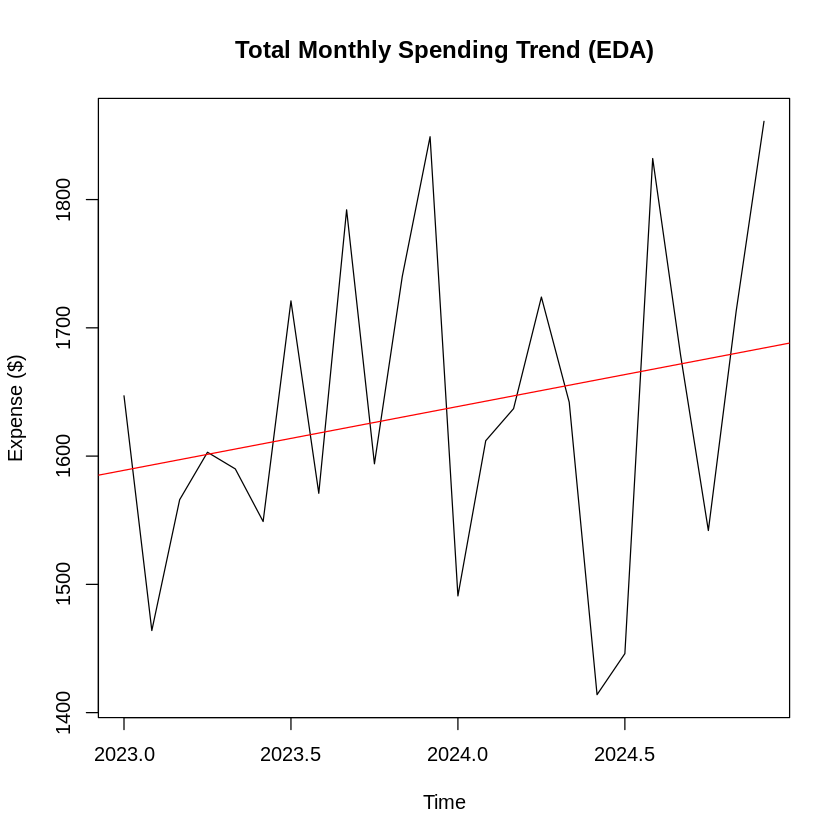

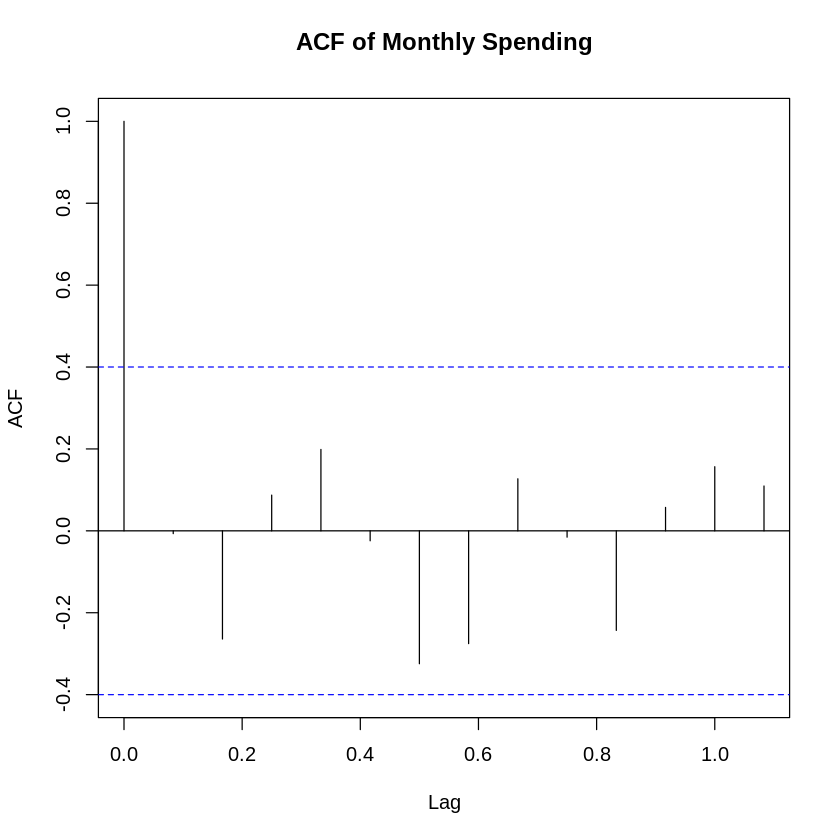

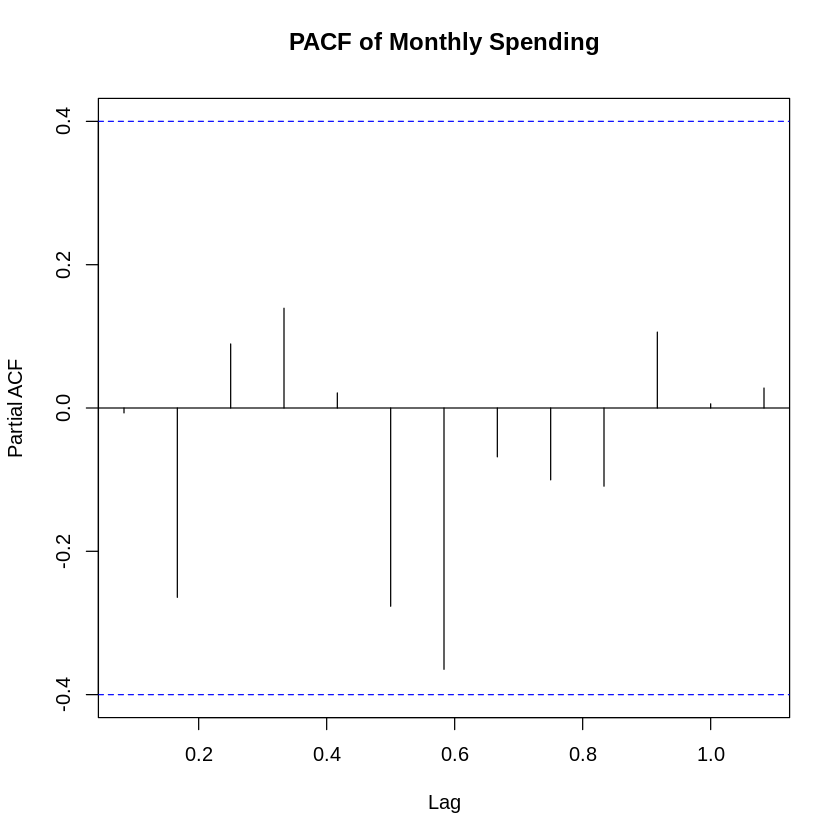

In [ ]:
# ----------------------------------------------------
# STEP 3 & 4: Cleaning & EDA
# ----------------------------------------------------

# Step 3: Data Cleaning and Preprocessing (Aggregation is already done in mock data)
# In a real scenario, you would aggregate transaction-level data here:
# monthly_spending <- raw_data %>%
#   mutate(Month = floor_date(Date, "month")) %>%
#   group_by(Month) %>%
#   summarise(Total_Expense = sum(Amount_Spent))

# Convert the monthly totals into a Time Series (TS) object
# Assuming monthly frequency (freq=12)
monthly_ts <- ts(mock_data$Total_Expense,
                 start = c(year(start_date), month(start_date)),
                 frequency = 12)

# Step 4: Exploratory Data Analysis (EDA)
# Plot the Time Series to check for trend, seasonality, and stationarity
plot(monthly_ts, main = "Total Monthly Spending Trend (EDA)", ylab = "Expense ($)")
abline(reg = lm(monthly_ts ~ time(monthly_ts)), col = "red") # Add trend line

# Check Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)
# to help identify appropriate ARIMA model parameters.
acf(monthly_ts, main = "ACF of Monthly Spending")
pacf(monthly_ts, main = "PACF of Monthly Spending")

Series: monthly_ts 
ARIMA(0,0,0) with non-zero mean 

Coefficients:
           mean
      1636.6250
s.e.    24.9836

sigma^2 = 15632:  log likelihood = -149.43
AIC=302.86   AICc=303.43   BIC=305.21

Training set error measures:
                        ME     RMSE      MAE        MPE     MAPE     MASE
Training set -4.542926e-10 122.3938 99.79167 -0.5602346 6.122915 0.841532
                     ACF1
Training set -0.006798585

	Ljung-Box test

data:  Residuals from ARIMA(0,0,0) with non-zero mean
Q* = 3.4582, df = 5, p-value = 0.6297

Model df: 0.   Total lags used: 5

[1] "--- Final Expense Forecast for the Next 3 Months (Interpretation) ---"
         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Jan 2025       1636.625 1476.397 1796.853 1391.578 1881.672
Feb 2025       1636.625 1476.397 1796.853 1391.578 1881.672
Mar 2025       1636.625 1476.397 1796.853 1391.578 1881.672


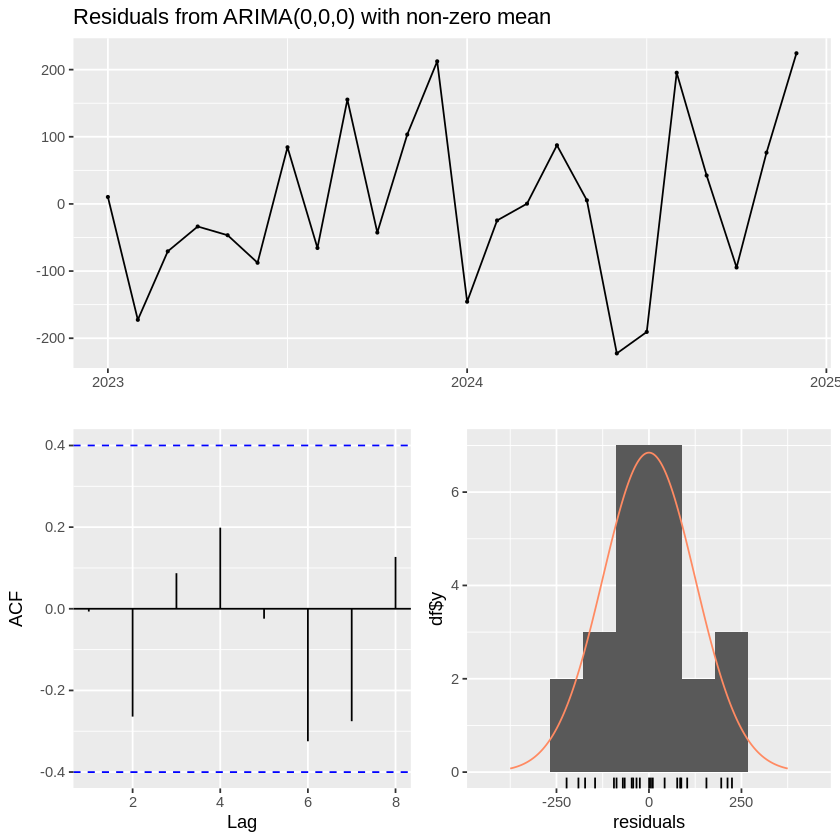

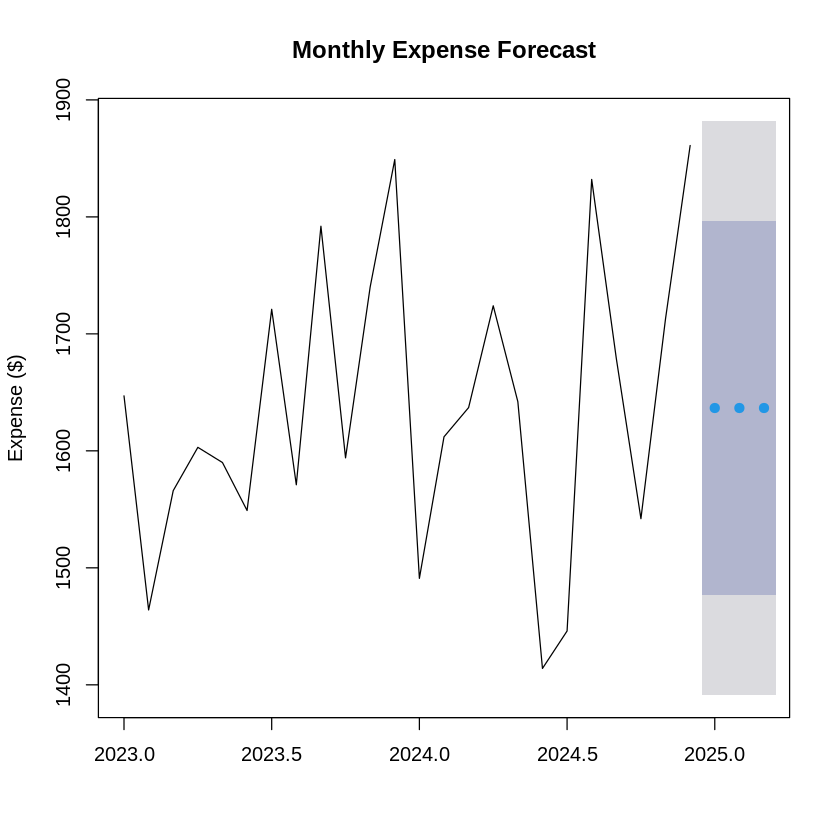

In [ ]:
# ----------------------------------------------------
# STEP 5 & 6: Model Building & Evaluation
# ----------------------------------------------------

# Step 5: Model Building
# Use auto.arima() to automatically select the best ARIMA model parameters
# based on AIC, AICc, or BIC values.
arima_model <- auto.arima(monthly_ts)

# Print the model summary to see the chosen parameters (p, d, q)
print(summary(arima_model))

# Step 6: Evaluation and Interpretation
# Check model residuals (should be normally distributed and uncorrelated)
checkresiduals(arima_model)

# Generate a forecast for the next 3 months (h=3)
forecast_result <- forecast(arima_model, h = 3)

# Print the final forecast values (Interpretation)
print("--- Final Expense Forecast for the Next 3 Months (Interpretation) ---")
print(forecast_result)

# Plot the forecast
plot(forecast_result, main = "Monthly Expense Forecast", ylab = "Expense ($)")

In [ ]:
# ----------------------------------------------------
# STEP 7: Preparation for Power BI
# ----------------------------------------------------

# Create a data frame with the forecast for easy export and Power BI visualization
forecast_df <- data.frame(forecast_result) %>%
  rownames_to_column(var = "Period") %>%
  # Extract only the predicted mean value
  select(Period, Predicted_Expense = Point.Forecast) %>%
  mutate(Type = "Forecast")

# Create a data frame for the historical data
historical_df <- data.frame(
  Period = time(monthly_ts),
  Predicted_Expense = monthly_ts,
  Type = "Historical"
)

# Combine for a single visualization in Power BI
final_report_data <- bind_rows(
  historical_df %>% rename(Period = Period),
  forecast_df %>% mutate(Period = as.numeric(gsub("Point\\s", "", Period)) + max(historical_df$Period))
)

# Save the combined data to a CSV file.
# This CSV file will be imported into Power BI for the final presentation.
write_csv(final_report_data, "Budget_Prediction_Report_Data.csv")

print("Data exported to 'Budget_Prediction_Report_Data.csv' for Power BI.")

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `Period = as.numeric(gsub("Point\\s", "", Period)) +
  max(historical_df$Period)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Data exported to 'Budget_Prediction_Report_Data.csv' for Power BI."


In [ ]:
# ----------------------------------------------------
# STEP 7: Preparation for Power BI (FIXED)
# ----------------------------------------------------

# 1. Create a data frame for the historical data
historical_df <- data.frame(
  Period_Numeric = time(monthly_ts), # Uses the numeric R time index (e.g., 2023.0833, 2023.1667, ...)
  Expense = monthly_ts,
  Type = "Historical"
)

# 2. Create a data frame with the forecast
forecast_df <- data.frame(forecast_result) %>%
  # Create a numeric index for the forecast periods starting after the last historical period
  mutate(
    Period_Numeric = max(historical_df$Period_Numeric) + (1:n() / 12),
    Expense = Point.Forecast,
    Type = "Forecast"
  ) %>%
  select(Period_Numeric, Expense, Type) # Keep only necessary columns

# 3. Combine for a single visualization in Power BI
final_report_data <- bind_rows(historical_df, forecast_df)

# Save the combined data to a CSV file.
write_csv(final_report_data, "Budget_Prediction_Report_Data.csv")

print("Data exported to 'Budget_Prediction_Report_Data.csv' for Power BI.")

[1] "Data exported to 'Budget_Prediction_Report_Data.csv' for Power BI."


In [ ]:
# ----------------------------------------------------
# 7. VISUALIZATION USING GGPLOT2 (The Final Chart)
# ----------------------------------------------------

# Install ggplot2 and reshape2 if needed
# install.packages(c("ggplot2", "reshape2"))
library(ggplot2)
library(reshape2)

# 1. Prepare Confidence Interval Data (Melt the bounds for the shaded area)
# Get the CI bounds from the forecast object and align them for plotting
ci_df <- data.frame(
  Period_Numeric = time(forecast_result$mean),
  Lower_80 = forecast_result$lower[, 1],  # 80% CI Lower Bound
  Upper_80 = forecast_result$upper[, 1],  # 80% CI Upper Bound
  Lower_95 = forecast_result$lower[, 2],  # 95% CI Lower Bound
  Upper_95 = forecast_result$upper[, 2]   # 95% CI Upper Bound
)

# 2. Main Visualization with Confidence Intervals
final_plot <- ggplot() +

  # --- 95% Confidence Interval (Light Shaded Area: The 'Safe Zone') ---
  geom_ribbon(data = ci_df, aes(x = Period_Numeric, ymin = Lower_95, ymax = Upper_95),
              fill = "#ADD8E6", alpha = 0.3) + # Light Blue Shade

  # --- Historical Data (Actual Spending) ---
  geom_line(data = subset(final_report_data, Type == "Historical"),
            aes(x = Period_Numeric, y = Expense, color = "Historical Actuals"), size = 1) +

  # --- Point Forecast (The Prediction) ---
  geom_line(data = subset(final_report_data, Type == "Forecast"),
            aes(x = Period_Numeric, y = Expense, color = "Forecast"), size = 1.2, linetype = "dashed") +

  # --- Styling ---
  labs(title = "Monthly Expense Forecast & Risk Management",
       subtitle = "Actual Spending (Jan 2023 - Aug 2025) vs. ARIMA Prediction",
       x = "Year",
       y = "Total Monthly Expense ($)",
       caption = "Shaded area represents 95% Confidence Interval (Safe Spending Range)") +

  scale_color_manual(name = "",
                     values = c("Historical Actuals" = "#0072B2", "Forecast" = "#D55E00")) +

  theme_minimal() +
  theme(legend.position = "bottom",
        plot.title = element_text(face = "bold"))

# Display the final plot
print(final_plot)



ERROR: Error in library(reshape2): there is no package called ‘reshape2’


[1] "Objective: Forecast the total monthly expenses for the next 3 months."
[1] "--- Mock Data Sample ---"


Date,Total_Expense
<date>,<dbl>
2023-01-01,1647
2023-02-01,1464
2023-03-01,1566
2023-04-01,1603
2023-05-01,1590
2023-06-01,1549


[1] "--- ARIMA Model Summary (Step 5) ---"
Series: monthly_ts 
ARIMA(0,0,0) with non-zero mean 

Coefficients:
           mean
      1636.6250
s.e.    24.9836

sigma^2 = 15632:  log likelihood = -149.43
AIC=302.86   AICc=303.43   BIC=305.21

Training set error measures:
                        ME     RMSE      MAE        MPE     MAPE     MASE
Training set -4.542926e-10 122.3938 99.79167 -0.5602346 6.122915 0.841532
                     ACF1
Training set -0.006798585
[1] "--- Final 3-Month Expense Forecast (Step 6 Interpretation) ---"
         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Jan 2025       1636.625 1476.397 1796.853 1391.578 1881.672
Feb 2025       1636.625 1476.397 1796.853 1391.578 1881.672
Mar 2025       1636.625 1476.397 1796.853 1391.578 1881.672


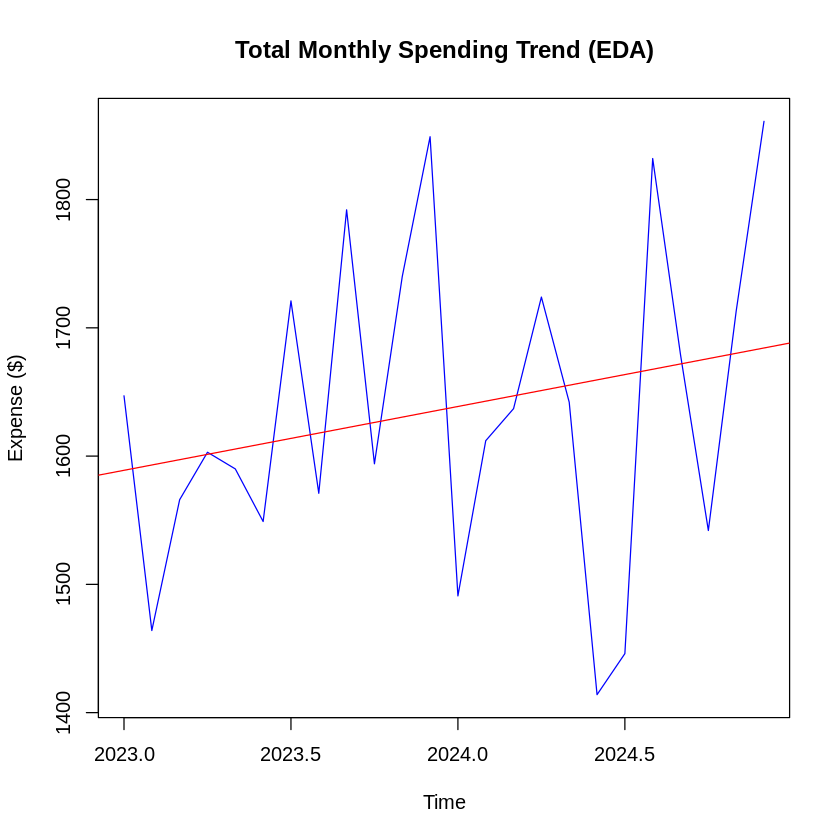

[1] "================================================================"
[1] "SUCCESS: Data exported to 'Budget_Prediction_Report_Data.csv'."
[1] "Import this CSV into Power BI for final dashboard visualization."
[1] "================================================================"


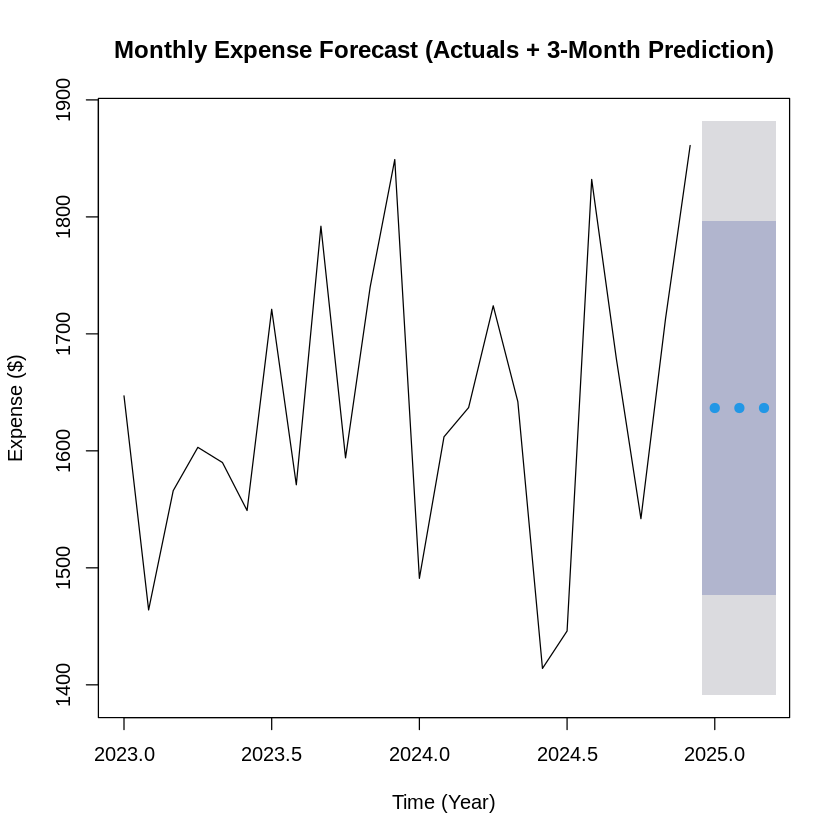

In [ ]:
# Define the Objective (Step 1)
print("Objective: Forecast the total monthly expenses for the next 3 months.")

# Create a MOCK Transaction Dataset (Step 2 - Simulate 2 years of monthly data)
set.seed(42)
num_months <- 24
start_date <- ymd("2023-01-01")

mock_data <- tibble(
  Date = seq(start_date, by = "month", length.out = num_months)
) %>%
  # Simulate monthly total spending with a slight upward trend and some noise
  mutate(
    BaseExpense = 1500 + (row_number() * 10),
    Noise = rnorm(num_months, mean = 0, sd = 100),
    Total_Expense = round(BaseExpense + Noise, 0)
  ) %>%
  select(Date, Total_Expense)

# View the first few rows of the mock data
print("--- Mock Data Sample ---")
head(mock_data)


# ----------------------------------------------------
# 3 & 4. Data Cleaning, Time Series Conversion, and EDA
# ----------------------------------------------------

# Step 3: Data Cleaning/Conversion
# Convert the monthly totals into a Time Series (TS) object (frequency=12 for monthly)
monthly_ts <- ts(mock_data$Total_Expense,
                 start = c(year(start_date), month(start_date)),
                 frequency = 12)

# Step 4: Exploratory Data Analysis (EDA)
# Plot the Time Series to check for trend and seasonality
plot(monthly_ts,
     main = "Total Monthly Spending Trend (EDA)",
     ylab = "Expense ($)",
     col = "blue")
abline(reg = lm(monthly_ts ~ time(monthly_ts)), col = "red") # Trend line

# Check Autocorrelation Function (ACF) for model parameter guidance
# acf(monthly_ts, main = "ACF of Monthly Spending")


# ----------------------------------------------------
# 5 & 6. Model Building, Evaluation, and Forecast
# ----------------------------------------------------

# Step 5: Model Building
# Use auto.arima() to automatically select the best ARIMA model
arima_model <- auto.arima(monthly_ts)

# Print the model summary (Evaluation & Model specifics)
print("--- ARIMA Model Summary (Step 5) ---")
print(summary(arima_model))

# Check model residuals for diagnostics (should show random noise)
# checkresiduals(arima_model)

# Step 6: Generate a forecast for the next 3 months (h=3)
forecast_result <- forecast(arima_model, h = 3)

# Print the final forecast values (Interpretation)
print("--- Final 3-Month Expense Forecast (Step 6 Interpretation) ---")
print(forecast_result)

# Plot the forecast
plot(forecast_result,
     main = "Monthly Expense Forecast (Actuals + 3-Month Prediction)",
     ylab = "Expense ($)",
     xlab = "Time (Year)")


# ----------------------------------------------------
# 7. Preparation for Power BI Export (Clean Dataframe)
# ----------------------------------------------------

# Create a data frame for the historical data
historical_df <- data.frame(
  Period_Numeric = time(monthly_ts), # Numeric R time index (e.g., 2023.0833)
  Expense = monthly_ts,
  Type = "Historical"
)

# Create a data frame with the forecast (using the cleaned time index method)
# 'forecast_result' is a list, extracting the numeric point forecast
forecast_df <- data.frame(
    Expense = forecast_result$mean,
    Type = "Forecast"
  ) %>%
  mutate(
    # Calculate the continuous numeric index for the forecast periods
    Period_Numeric = max(historical_df$Period_Numeric) + (1:n() / 12)
  ) %>%
  select(Period_Numeric, Expense, Type)

# Combine historical and forecast data for a single Power BI source
final_report_data <- bind_rows(historical_df, forecast_df)

# Save the combined data to a CSV file.
write_csv(final_report_data, "Budget_Prediction_Report_Data.csv")

print("================================================================")
print("SUCCESS: Data exported to 'Budget_Prediction_Report_Data.csv'.")
print("Import this CSV into Power BI for final dashboard visualization.")
print("================================================================")

In [ ]:
# ----------------- REVISED LINES START HERE -----------------

# Define the total number of months needed to end in August 2025.
# (2023: 12 months) + (2024: 12 months) + (2025: 8 months) = 32 months
num_months <- 32
start_date <- ymd("2023-01-01") # Starting point remains the same

# Create a MOCK Transaction Dataset
mock_data <- tibble(
  Date = seq(start_date, by = "month", length.out = num_months)
) %>%
  # ... (rest of the simulation logic remains the same) ...

ERROR: Error in parse(text = input): <text>:13:0: unexpected end of input
11: ) %>%
12:   # ... (rest of the simulation logic remains the same) ...
   ^


In [ ]:
# Define the Objective (Step 1)
print("Objective: Forecast the total monthly expenses for the next 3 months.")

# --- REVISED MOCK DATA PARAMETERS (Historical data ends August 2025) ---
# Define the total number of months needed to end in August 2025.
# (2023: 12 months) + (2024: 12 months) + (2025: 8 months) = 32 months
num_months <- 32
start_date <- ymd("2023-01-01") # Starting point remains the same

# Create a MOCK Transaction Dataset
set.seed(42) # Ensure reproducible randomness
mock_data <- tibble(
  Date = seq(start_date, by = "month", length.out = num_months)
) %>%
  # Simulate monthly total spending with a slight upward trend and some noise
  mutate(
    BaseExpense = 1500 + (row_number() * 10),
    Noise = rnorm(num_months, mean = 0, sd = 100),
    Total_Expense = round(BaseExpense + Noise, 0)
  ) %>%
  select(Date, Total_Expense)

# View the first few rows of the mock data
print("--- Mock Data Sample (Ending August 2025) ---")
tail(mock_data)
# The last rows should show dates in 2025 up to August, confirming the change.

[1] "Objective: Forecast the total monthly expenses for the next 3 months."
[1] "--- Mock Data Sample (Ending August 2025) ---"


Date,Total_Expense
<date>,<dbl>
2025-03-01,1744
2025-04-01,1604
2025-05-01,1836
2025-06-01,1736
2025-07-01,1856
2025-08-01,1890
